<a href="https://colab.research.google.com/github/rahitmaity231-lang/AI_LAB/blob/main/Lab1_Q3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

          CITY ROUTE CHECKING USING DFS

Road Network (Adjacency List):
Delhi      -> ['Agra', 'Jaipur']
Agra       -> ['Delhi', 'Lucknow']
Jaipur     -> ['Delhi', 'Udaipur']
Lucknow    -> ['Agra', 'Varanasi']
Varanasi   -> ['Lucknow']
Udaipur    -> ['Jaipur']
Mumbai     -> ['Pune']
Pune       -> ['Mumbai']

-----------------------------------------------------------------

Checking route from Delhi to Varanasi:
✓ Route EXISTS

-----------------------------------------------------------------

CONNECTED COMPONENTS:
Component 1: Delhi → Agra → Lucknow → Varanasi → Jaipur → Udaipur
Component 2: Mumbai → Pune

Total connected components = 2


DFS Route Found:
Delhi → Agra → Lucknow → Varanasi


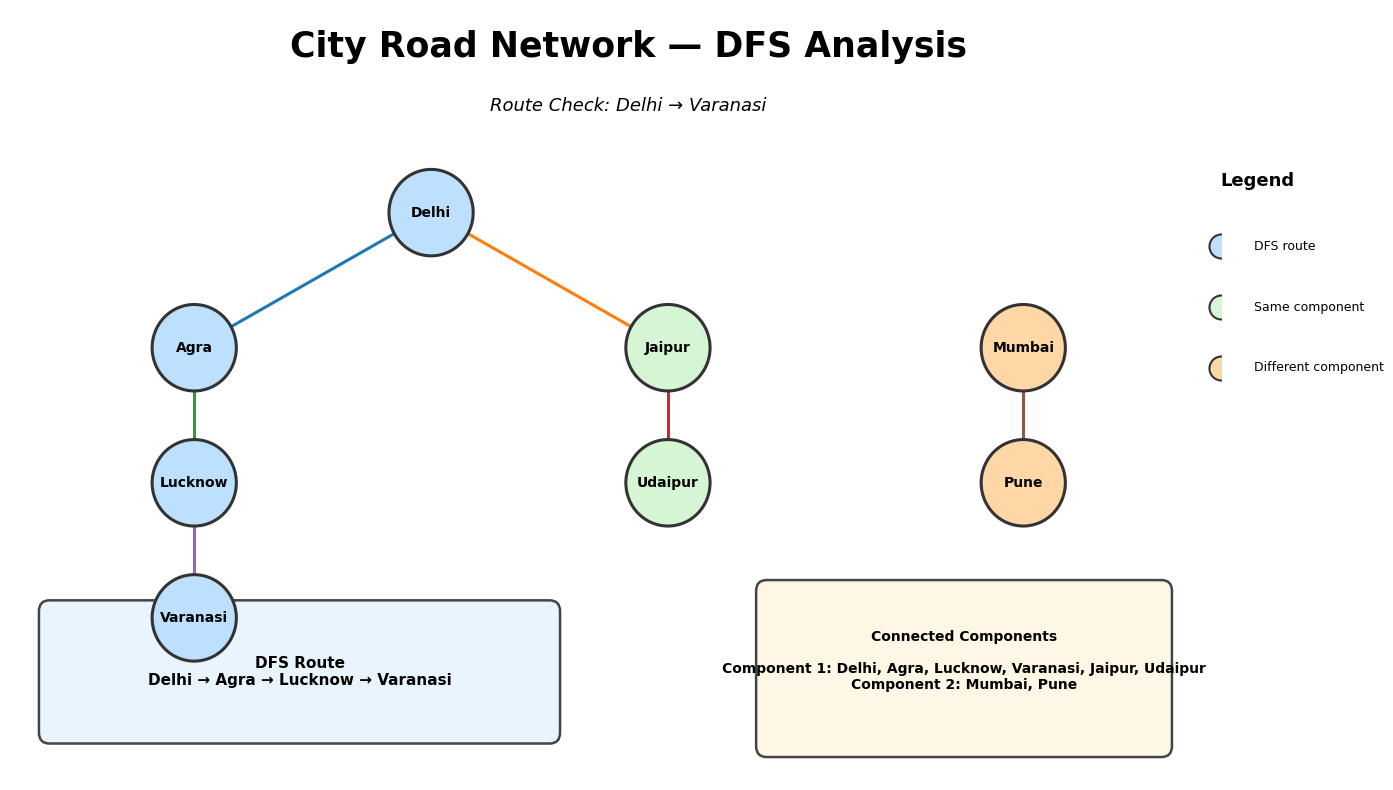

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch


# ============================================================
# PROBLEM 3: CHECKING ROUTES BETWEEN CITIES USING DFS
# ============================================================

# ------------------------------------------------------------
# 1. ROAD NETWORK USING AN ADJACENCY LIST
# ------------------------------------------------------------

# The graph is UNDIRECTED because roads connect cities
# in both directions.

graph = {
    "Delhi": ["Agra", "Jaipur"],
    "Agra": ["Delhi", "Lucknow"],
    "Jaipur": ["Delhi", "Udaipur"],
    "Lucknow": ["Agra", "Varanasi"],
    "Varanasi": ["Lucknow"],
    "Udaipur": ["Jaipur"],
    "Mumbai": ["Pune"],
    "Pune": ["Mumbai"]
}


# ============================================================
# 2. DFS TO CHECK WHETHER A ROUTE EXISTS
# ============================================================

def route_exists(graph, start, destination):
    """
    Uses DFS to check whether a route exists between
    start city and destination city.
    """

    visited = set()

    def dfs(city):

        # Destination found
        if city == destination:
            return True

        visited.add(city)

        # Visit all neighbouring cities
        for neighbour in graph[city]:

            if neighbour not in visited:

                if dfs(neighbour):
                    return True

        return False

    return dfs(start)


# ============================================================
# 3. DFS TO FIND ALL CITIES IN ONE CONNECTED COMPONENT
# ============================================================

def dfs_component(graph, start, visited):
    """
    Performs DFS starting from one city and finds all cities
    connected to that city.
    """

    component = []

    def dfs(city):

        visited.add(city)
        component.append(city)

        for neighbour in graph[city]:

            if neighbour not in visited:
                dfs(neighbour)

    dfs(start)

    return component


# ============================================================
# 4. FIND ALL CONNECTED COMPONENTS
# ============================================================

def find_connected_components(graph):

    visited = set()
    components = []

    for city in graph:

        if city not in visited:

            component = dfs_component(
                graph,
                city,
                visited
            )

            components.append(component)

    return components


# ============================================================
# 5. SELECT TWO CITIES TO CHECK
# ============================================================

start_city = "Delhi"
destination_city = "Varanasi"


# ============================================================
# 6. CHECK WHETHER ROUTE EXISTS
# ============================================================

route_found = route_exists(
    graph,
    start_city,
    destination_city
)


# ============================================================
# 7. FIND CONNECTED COMPONENTS
# ============================================================

components = find_connected_components(graph)


# ============================================================
# 8. PRINT RESULTS
# ============================================================

print("=" * 65)
print("          CITY ROUTE CHECKING USING DFS")
print("=" * 65)

print("\nRoad Network (Adjacency List):")

for city, neighbours in graph.items():
    print(f"{city:10} -> {neighbours}")


print("\n" + "-" * 65)

print(
    f"\nChecking route from {start_city} "
    f"to {destination_city}:"
)

if route_found:
    print("✓ Route EXISTS")
else:
    print("✗ Route DOES NOT EXIST")


print("\n" + "-" * 65)

print("\nCONNECTED COMPONENTS:")

for i, component in enumerate(components, start=1):

    print(
        f"Component {i}: "
        + " → ".join(component)
    )

print(
    f"\nTotal connected components = {len(components)}"
)

print("\n" + "=" * 65)


# ============================================================
# 9. FIND AN ACTUAL DFS ROUTE
# ============================================================

def find_route_dfs(graph, start, destination):

    visited = set()
    path = []

    def dfs(city):

        visited.add(city)
        path.append(city)

        if city == destination:
            return True

        for neighbour in graph[city]:

            if neighbour not in visited:

                if dfs(neighbour):
                    return True

        # Backtrack
        path.pop()
        return False

    if dfs(start):
        return path

    return None


route = find_route_dfs(
    graph,
    start_city,
    destination_city
)


# ============================================================
# 10. PRINT ACTUAL ROUTE
# ============================================================

if route:

    print("\nDFS Route Found:")
    print(" → ".join(route))

else:

    print("\nNo route found.")


# ============================================================
# 11. CITY POSITIONS FOR VISUALIZATION
# ============================================================

positions = {
    "Delhi": (0, 3),
    "Agra": (-1.8, 2),
    "Jaipur": (1.8, 2),
    "Lucknow": (-1.8, 1),
    "Varanasi": (-1.8, 0),
    "Udaipur": (1.8, 1),
    "Mumbai": (4.5, 2),
    "Pune": (4.5, 1)
}


# ============================================================
# 12. CREATE MATPLOTLIB FIGURE
# ============================================================

fig, ax = plt.subplots(figsize=(14, 8))

ax.set_xlim(-3.2, 6)
ax.set_ylim(-1.2, 4.5)

ax.axis("off")


# ============================================================
# 13. TITLE
# ============================================================

ax.text(
    1.5,
    4.15,
    "City Road Network — DFS Analysis",
    fontsize=25,
    fontweight="bold",
    ha="center"
)

ax.text(
    1.5,
    3.75,
    f"Route Check: {start_city} → {destination_city}",
    fontsize=13,
    ha="center",
    style="italic"
)


# ============================================================
# 14. DRAW ROAD CONNECTIONS
# ============================================================

drawn_edges = set()

for city, neighbours in graph.items():

    for neighbour in neighbours:

        # Avoid drawing the same undirected edge twice
        edge = tuple(sorted([city, neighbour]))

        if edge in drawn_edges:
            continue

        drawn_edges.add(edge)

        x1, y1 = positions[city]
        x2, y2 = positions[neighbour]

        ax.plot(
            [x1, x2],
            [y1, y2],
            linewidth=2.2,
            zorder=1
        )


# ============================================================
# 15. DETERMINE CITIES IN THE SELECTED ROUTE
# ============================================================

route_set = set(route) if route else set()


# ============================================================
# 16. DETERMINE COMPONENT NUMBER FOR EACH CITY
# ============================================================

city_component = {}

for number, component in enumerate(components, start=1):

    for city in component:

        city_component[city] = number


# ============================================================
# 17. DRAW CITY NODES
# ============================================================

for city, (x, y) in positions.items():

    component_number = city_component[city]

    # Cities belonging to the selected route
    if city in route_set:
        face_color = "#BDE0FE"

    # Cities in another disconnected component
    elif component_number != city_component[start_city]:
        face_color = "#FFD6A5"

    else:
        face_color = "#D5F5D5"

    circle = plt.Circle(
        (x, y),
        0.32,
        facecolor=face_color,
        edgecolor="#333333",
        linewidth=2.2,
        zorder=3
    )

    ax.add_patch(circle)

    # City name
    ax.text(
        x,
        y,
        city,
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        zorder=4
    )


# ============================================================
# 18. ADD ROUTE INFORMATION BOX
# ============================================================

route_text = (
    "DFS Route\n"
    + (" → ".join(route) if route else "No route exists")
)

route_box = FancyBboxPatch(
    (-2.9, -0.85),
    3.8,
    0.9,
    boxstyle="round,pad=0.08,rounding_size=0.08",
    facecolor="#EAF4FF",
    edgecolor="#444444",
    linewidth=1.8
)

ax.add_patch(route_box)

ax.text(
    -1.0,
    -0.40,
    route_text,
    ha="center",
    va="center",
    fontsize=11,
    fontweight="bold"
)


# ============================================================
# 19. ADD CONNECTED COMPONENT INFORMATION
# ============================================================

component_text = "Connected Components\n\n"

for i, component in enumerate(components, start=1):

    component_text += (
        f"Component {i}: "
        + ", ".join(component)
        + "\n"
    )


component_box = FancyBboxPatch(
    (2.55, -0.95),
    3.0,
    1.15,
    boxstyle="round,pad=0.08,rounding_size=0.08",
    facecolor="#FFF7E6",
    edgecolor="#444444",
    linewidth=1.8
)

ax.add_patch(component_box)

ax.text(
    4.05,
    -0.38,
    component_text,
    ha="center",
    va="center",
    fontsize=10,
    fontweight="bold"
)


# ============================================================
# 20. LEGEND
# ============================================================

ax.text(
    6.0,
    3.2,
    "Legend",
    fontsize=13,
    fontweight="bold"
)

legend_items = [
    ("#BDE0FE", "DFS route"),
    ("#D5F5D5", "Same component"),
    ("#FFD6A5", "Different component")
]

for i, (color, label) in enumerate(legend_items):

    y = 2.75 - i * 0.45

    ax.scatter(
        6.0,
        y,
        s=300,
        facecolor=color,
        edgecolor="#333333",
        linewidth=1.5
    )

    ax.text(
        6.25,
        y,
        label,
        va="center",
        fontsize=9
    )


# ============================================================
# 21. FINAL DISPLAY
# ============================================================

plt.tight_layout()

plt.show()